# WS2 Results Overview — Gemma 3 4B IT

Analyzes results from Exp 2.1 (EVA JS divergence), Exp 2.2 (EVA decoding), Exp 2.4 (Chain-of-Embedding / VIP / TVI), and Exp 2.5 (SAE Convergence).

**Model:** `google/gemma-3-4b-it`  
**Benchmarks:** VLMs Are Biased (VAB), ViLP, VLind-Bench  
**Goal:** Identify the WS3 target layer from the intersection of VIP and SAE convergence.

In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
RESULTS = Path('../results')
MODEL   = 'google_gemma-3-4b-it'

DATASETS = ['vlms_are_biased', 'vilp', 'vlind']
LABELS   = {'vlms_are_biased': 'VAB', 'vilp': 'ViLP', 'vlind': 'VLind'}
COLORS   = {'vlms_are_biased': 'steelblue', 'vilp': 'coral', 'vlind': 'seagreen'}

## 1. Chain-of-Embedding: VIP and TVI

In [34]:
coe_summaries, coe_distances, coe_tvi = {}, {}, {}
for ds in DATASETS:
    base = RESULTS / 'chain_of_embedding' / MODEL / ds
    with open(base / 'summary.json') as f:
        coe_summaries[ds] = json.load(f)
    coe_distances[ds] = np.load(base / 'distances.npz', allow_pickle=True)
    coe_tvi[ds]       = np.load(base / 'tvi.npz',       allow_pickle=True)

print(f"{'Dataset':<20} {'VIP median':>10} {'VIP mean':>10} {'TVI mean':>10} {'n_dvt':>7} {'n_dt':>7}")
print('-' * 68)
for ds in DATASETS:
    s = coe_summaries[ds]
    print(f"{LABELS[ds]:<20} {s['vip_median']:>10} {s['vip_mean']:>10.1f} "
          f"{s['mean']:>10.5f} {s.get('n_dvt', 'N/A'):>7} {s.get('n_dt', 'N/A'):>7}")

Dataset              VIP median   VIP mean   TVI mean   n_dvt    n_dt
--------------------------------------------------------------------
VAB                          16       16.1    0.00020       0    2784
ViLP                         15       15.3    0.00024      43     257
VLind                        15       14.9    0.00009      29     273


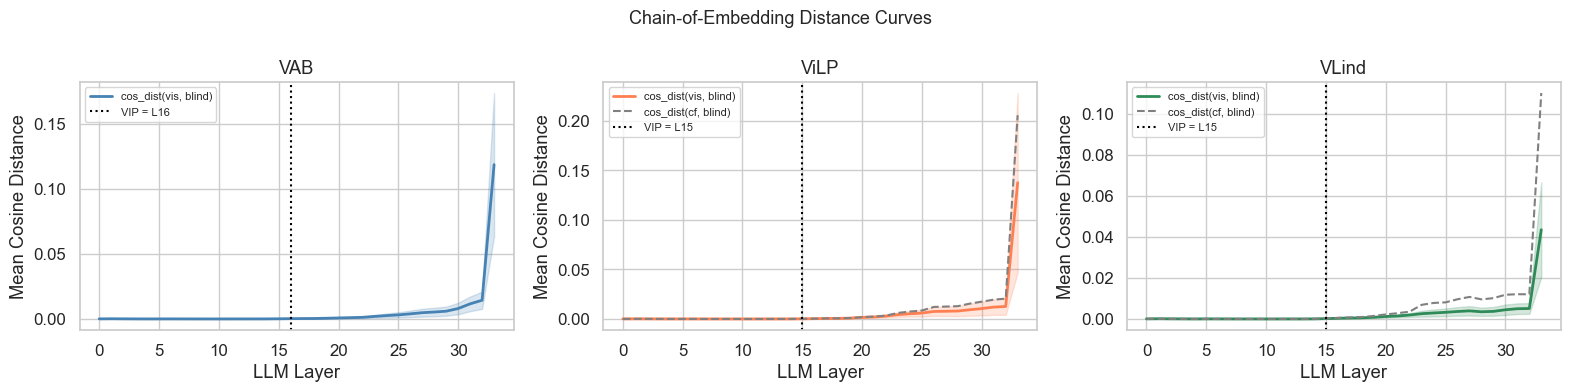

In [35]:
# Mean distance curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ds in zip(axes, DATASETS):
    d_vis = coe_distances[ds]['d_vis']
    mean_vis, std_vis = d_vis.mean(0), d_vis.std(0)
    layers = np.arange(len(mean_vis))
    vip = coe_summaries[ds]['vip_median']

    ax.plot(layers, mean_vis, color=COLORS[ds], lw=2, label='cos_dist(vis, blind)')
    ax.fill_between(layers, mean_vis - std_vis, mean_vis + std_vis, alpha=0.2, color=COLORS[ds])
    if coe_distances[ds]['d_cf'].ndim == 2 and coe_distances[ds]['d_cf'].shape[0] > 0:
        ax.plot(layers, coe_distances[ds]['d_cf'].mean(0), color='gray', lw=1.5,
                linestyle='--', label='cos_dist(cf, blind)')
    ax.axvline(vip, color='black', lw=1.5, linestyle=':', label=f'VIP = L{vip}')
    ax.set_title(LABELS[ds]); ax.set_xlabel('LLM Layer'); ax.set_ylabel('Mean Cosine Distance')
    ax.legend(fontsize=8)

fig.suptitle('Chain-of-Embedding Distance Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'chain_of_embedding' / 'vip_overview.png', dpi=150, bbox_inches='tight')
plt.show()

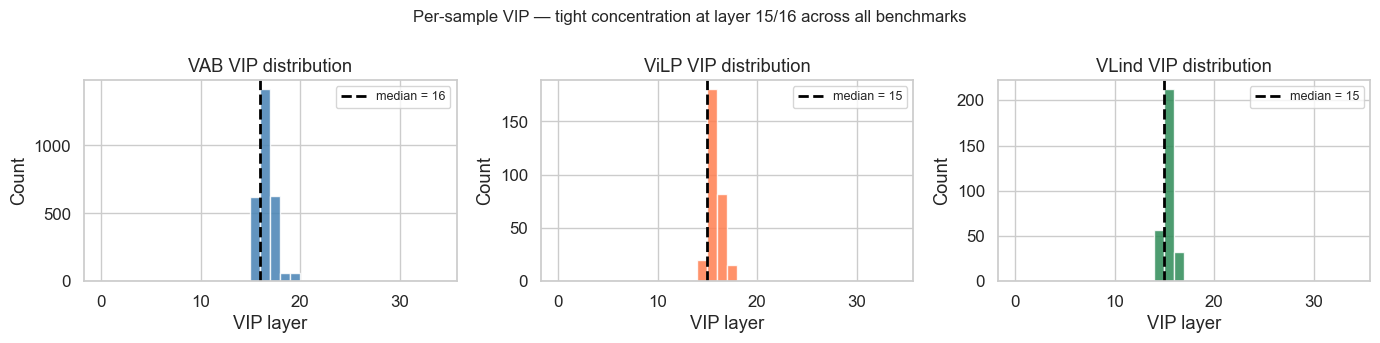

In [36]:
# VIP distribution histograms — one bin per layer
# Shows that almost every sample crosses the threshold at the same layer
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, ds in zip(axes, DATASETS):
    vips = coe_tvi[ds]['vip']
    ax.hist(vips, bins=range(0, 35), color=COLORS[ds], edgecolor='white', alpha=0.85)
    ax.axvline(int(np.median(vips)), color='black', lw=2, linestyle='--',
               label=f'median = {int(np.median(vips))}')
    ax.set_title(f'{LABELS[ds]} VIP distribution')
    ax.set_xlabel('VIP layer'); ax.set_ylabel('Count'); ax.legend(fontsize=9)

plt.suptitle('Per-sample VIP — tight concentration at layer 15/16 across all benchmarks', fontsize=12)
plt.tight_layout()
plt.show()

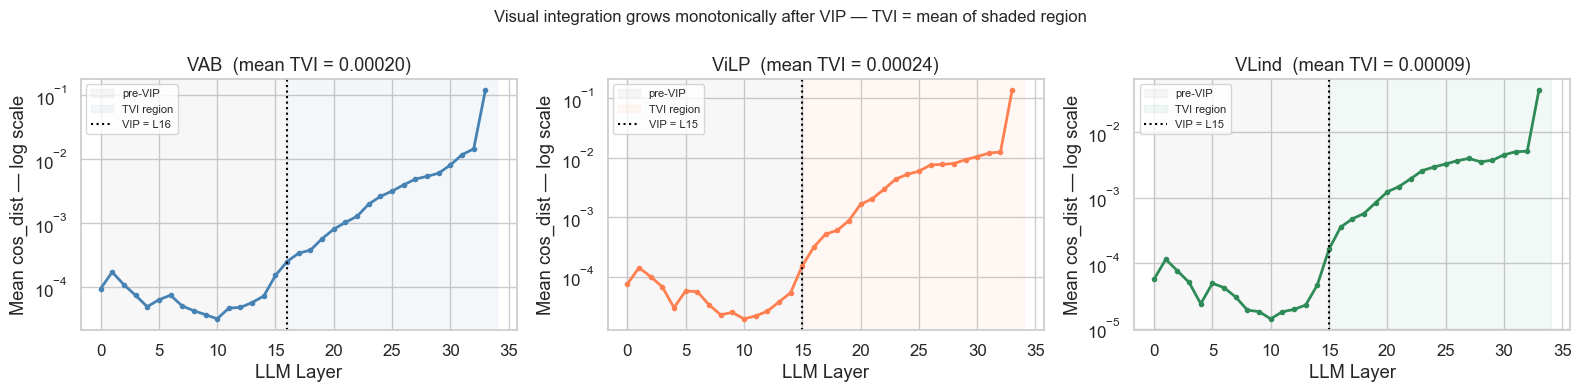

In [37]:
# Log-scale distance curves with VIP and TVI region shaded
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, ds in zip(axes, DATASETS):
    d_vis    = coe_distances[ds]['d_vis'].mean(0)
    layers   = np.arange(len(d_vis))
    vip      = coe_summaries[ds]['vip_median']
    tvi_mean = coe_summaries[ds]['mean']

    ax.axvspan(0, vip,            alpha=0.06, color='gray',       label='pre-VIP')
    ax.axvspan(vip, len(layers),  alpha=0.06, color=COLORS[ds],   label='TVI region')
    ax.semilogy(layers, np.maximum(d_vis, 1e-7), 'o-', color=COLORS[ds], lw=2, ms=3)
    ax.axvline(vip, color='black', lw=1.5, linestyle=':', label=f'VIP = L{vip}')
    ax.set_title(f'{LABELS[ds]}  (mean TVI = {tvi_mean:.5f})')
    ax.set_xlabel('LLM Layer'); ax.set_ylabel('Mean cos_dist — log scale')
    ax.legend(fontsize=8)

plt.suptitle('Visual integration grows monotonically after VIP — TVI = mean of shaded region', fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
# D_VT vs D_T summary table
print('D_VT = vision-dependent: answer changed with image AND correct')
print('D_T  = text-dependent:   answer same regardless of image\n')
print(f"{'Dataset':<10} {'TVI D_VT':>10} {'TVI D_T':>10} {'n_dvt':>7} {'% visual':>10}")
print('-' * 52)
for ds in DATASETS:
    s = coe_summaries[ds]
    n_dvt = s.get('n_dvt', 0); n_dt = s.get('n_dt', 0)
    pct = 100 * n_dvt / (n_dvt + n_dt) if (n_dvt + n_dt) > 0 else 0
    print(f"{LABELS[ds]:<10} {s.get('tvi_mean_dvt', float('nan')):>10.5f} "
          f"{s.get('tvi_mean_dt', float('nan')):>10.5f} {n_dvt:>7} {pct:>9.1f}%")
print('\nNOTE: VAB n_dvt=0 may be a bug (single-token decoding) — rerun pending.')

D_VT = vision-dependent: answer changed with image AND correct
D_T  = text-dependent:   answer same regardless of image

Dataset      TVI D_VT    TVI D_T   n_dvt   % visual
----------------------------------------------------
VAB               nan    0.00020       0       0.0%
ViLP          0.00035    0.00023      43      14.3%
VLind         0.00016    0.00009      29       9.6%

NOTE: VAB n_dvt=0 may be a bug (single-token decoding) — rerun pending.


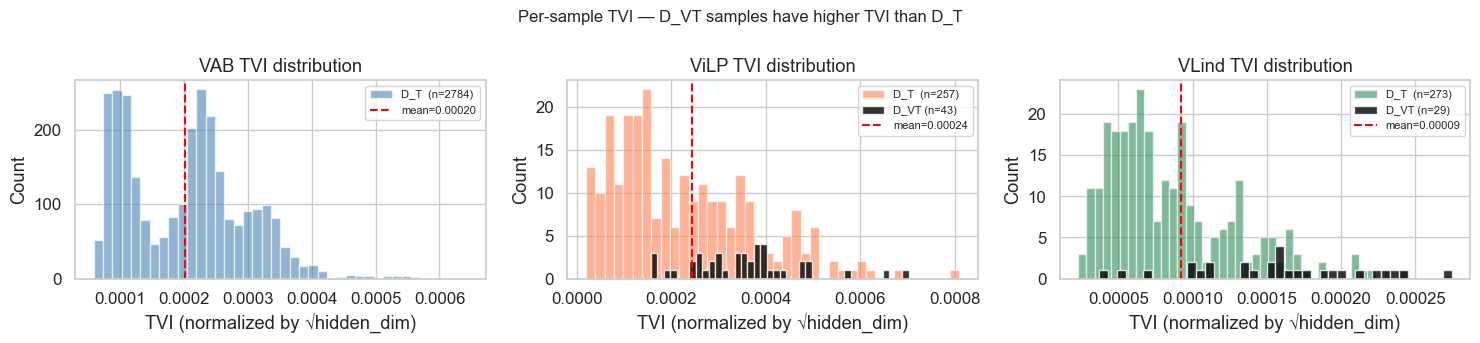

In [39]:
# TVI per-sample distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, ds in zip(axes, DATASETS):
    tvi     = coe_tvi[ds]['tvi']
    vis_dep = coe_tvi[ds]['is_vision_dependent'].astype(bool)
    ax.hist(tvi[~vis_dep], bins=40, color=COLORS[ds], alpha=0.6,
            label=f'D_T  (n={(~vis_dep).sum()})')
    if vis_dep.any():
        ax.hist(tvi[vis_dep], bins=40, color='black', alpha=0.8,
                label=f'D_VT (n={vis_dep.sum()})')
    ax.axvline(tvi.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={tvi.mean():.5f}')
    ax.set_title(f'{LABELS[ds]} TVI distribution')
    ax.set_xlabel('TVI (normalized by √hidden_dim)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

plt.suptitle('Per-sample TVI — D_VT samples have higher TVI than D_T', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/92/vn97p82j2sq0hx9c9xlrq70w0000gn/T/ipykernel_37661/2550522995.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,
/var/folders/92/vn97p82j2sq0hx9c9xlrq70w0000gn/T/ipykernel_37661/2550522995.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,


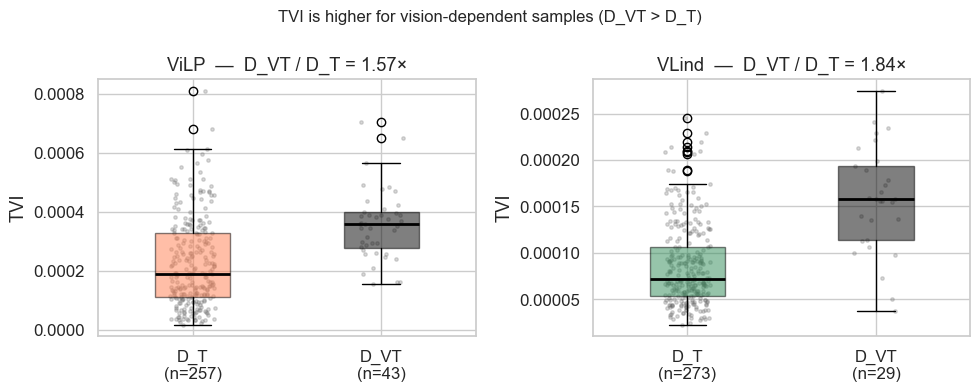

In [40]:
# D_VT vs D_T box plot
datasets_with_dvt = [ds for ds in DATASETS if coe_tvi[ds]['is_vision_dependent'].sum() > 0]
if not datasets_with_dvt:
    print('No datasets with D_VT samples yet — rerun chain-of-embedding with fix applied.')
else:
    fig, axes = plt.subplots(1, len(datasets_with_dvt), figsize=(5 * len(datasets_with_dvt), 4))
    if len(datasets_with_dvt) == 1: axes = [axes]
    rng = np.random.default_rng(42)
    for ax, ds in zip(axes, datasets_with_dvt):
        tvi     = coe_tvi[ds]['tvi']
        vis_dep = coe_tvi[ds]['is_vision_dependent'].astype(bool)
        groups  = [tvi[~vis_dep], tvi[vis_dep]]
        labels  = [f'D_T\n(n={(~vis_dep).sum()})', f'D_VT\n(n={vis_dep.sum()})']
        bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,
                        medianprops=dict(color='black', lw=2))
        bp['boxes'][0].set_facecolor(COLORS[ds]); bp['boxes'][0].set_alpha(0.5)
        bp['boxes'][1].set_facecolor('black');    bp['boxes'][1].set_alpha(0.5)
        for i, grp in enumerate(groups, start=1):
            ax.scatter(np.full(len(grp), i) + rng.uniform(-0.12, 0.12, len(grp)),
                       grp, alpha=0.25, s=6, color='dimgray')
        s = coe_summaries[ds]
        ratio = s['tvi_mean_dvt'] / s['tvi_mean_dt'] if s.get('tvi_mean_dt') else float('nan')
        ax.set_title(f"{LABELS[ds]}  —  D_VT / D_T = {ratio:.2f}×"); ax.set_ylabel('TVI')
    plt.suptitle('TVI is higher for vision-dependent samples (D_VT > D_T)', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS / 'chain_of_embedding' / 'tvi_dvt_vs_dt.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. EVA Decoding

**EVA** = **E**xtracting **V**isual f**A**cts from intermediate layers.

At each layer, compute JS divergence between multimodal and text-only next-token distributions. The peak layer is where visual information most strongly influences the prediction. EVA then injects this visual correction into the final logits:

```
p_EVA = softmax(log p_vis + α × (log p_vis − log p_blind))
```

**Exp 2.1:** Find peak layer on VQAv2.  
**Exp 2.2:** Apply EVA correction at that layer on the bias benchmarks.

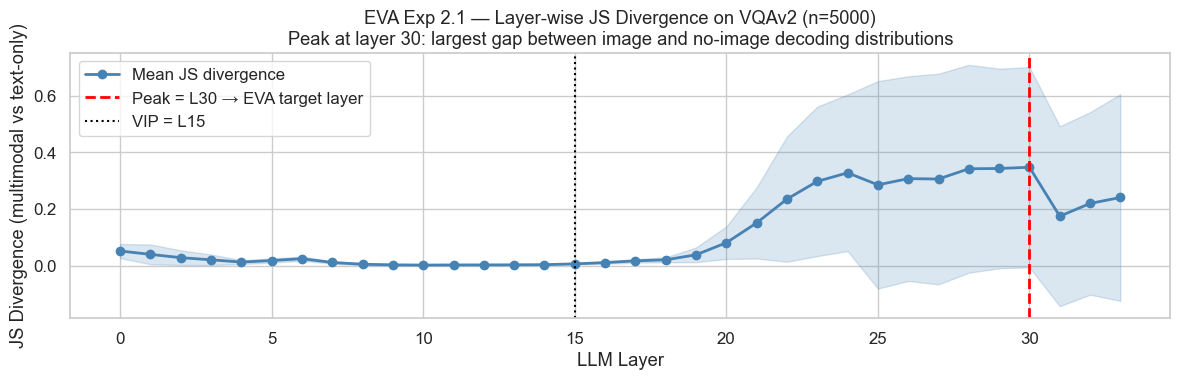

Peak JS divergence: layer 30 / 34 (88% depth)
VIP: layer 15 / 34 (44% depth)
Gap: 15 layers between visual integration onset (VIP) and peak information divergence (EVA)


In [41]:
# Exp 2.1 — JS divergence per layer on VQAv2
eva_js = np.load(RESULTS / 'eva' / 'vqav2' / 'js_per_layer.npz', allow_pickle=True)
with open(RESULTS / 'eva' / 'vqav2' / 'summary.json') as f:
    eva_summary = json.load(f)

mean_js = eva_js['mean_js']
std_js  = eva_js['std_js']
layers  = np.arange(len(mean_js))
peak    = eva_summary['peak_layer']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(layers, mean_js, 'o-', color='steelblue', lw=2, label='Mean JS divergence')
ax.fill_between(layers, mean_js - std_js, mean_js + std_js, alpha=0.2, color='steelblue')
ax.axvline(peak, color='red', lw=2, linestyle='--', label=f'Peak = L{peak} → EVA target layer')
ax.axvline(15, color='black', lw=1.5, linestyle=':', label='VIP = L15')
ax.set_xlabel('LLM Layer')
ax.set_ylabel('JS Divergence (multimodal vs text-only)')
ax.set_title(f'EVA Exp 2.1 — Layer-wise JS Divergence on VQAv2 (n=5000)\n'
             f'Peak at layer {peak}: largest gap between image and no-image decoding distributions')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'eva' / 'vqav2' / 'js_divergence_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak JS divergence: layer {peak} / {len(mean_js)} ({100*peak/len(mean_js):.0f}% depth)')
print(f'VIP: layer 15 / {len(mean_js)} ({100*15/len(mean_js):.0f}% depth)')
print(f'Gap: {peak - 15} layers between visual integration onset (VIP) and peak information divergence (EVA)')

In [42]:
# Exp 2.2 — EVA decoding accuracy sweep
eva_sweeps = {}
for ds in DATASETS:
    sweep_path = RESULTS / 'eva_decoding' / MODEL / ds / 'layer_30' / 'sweep_summary.json'
    if sweep_path.exists():
        with open(sweep_path) as f:
            eva_sweeps[ds] = json.load(f)
    else:
        partial = []
        for alpha in ['0.00', '0.50', '1.00', '2.00']:
            p = RESULTS / 'eva_decoding' / MODEL / ds / 'layer_30' / f'alpha_{alpha}' / 'summary.json'
            if p.exists():
                with open(p) as f: partial.append(json.load(f))
        if partial: eva_sweeps[ds] = partial

for ds, sweep in eva_sweeps.items():
    print(f'\n{LABELS[ds]}')
    print(f"  {'alpha':>6} {'vanilla':>9} {'eva':>9} {'delta':>9}")
    for r in sweep:
        print(f"  {r['alpha']:>6.1f} {r['vanilla_accuracy']:>9.3f} {r['eva_accuracy']:>9.3f} {r['accuracy_delta']:>+9.3f}")


VAB
   alpha   vanilla       eva     delta
     0.0     0.176     0.177    +0.001
     0.5     0.176     0.172    -0.004

ViLP
   alpha   vanilla       eva     delta
     0.0     0.713     0.713    +0.000
     0.5     0.713     0.683    -0.030
     1.0     0.713     0.667    -0.047
     2.0     0.713     0.613    -0.100

VLind
   alpha   vanilla       eva     delta
     0.0     0.103     0.103    +0.000
     0.5     0.103     0.119    +0.017
     1.0     0.103     0.132    +0.030
     2.0     0.103     0.142    +0.040


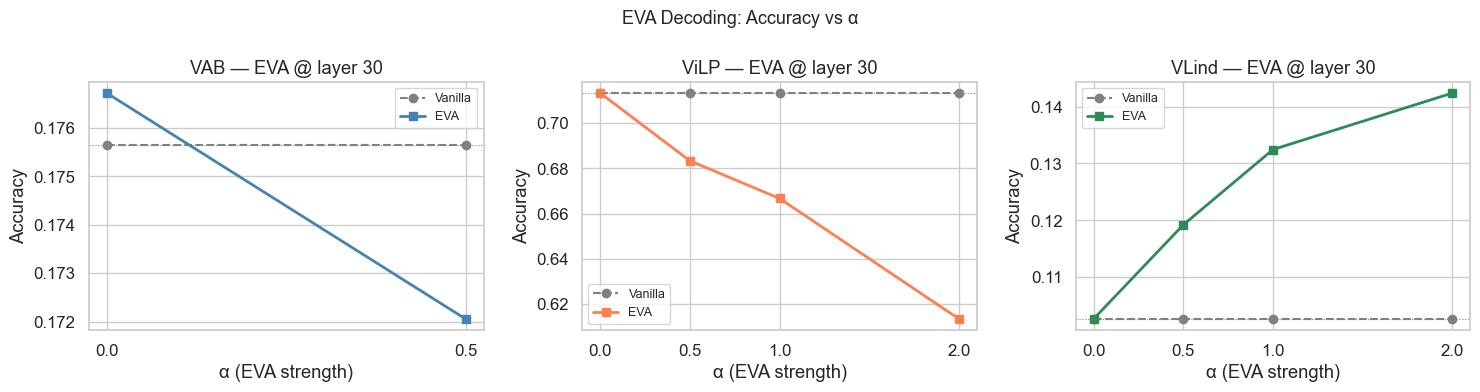

In [43]:
fig, axes = plt.subplots(1, len(eva_sweeps), figsize=(5 * len(eva_sweeps), 4), sharey=False)
if len(eva_sweeps) == 1: axes = [axes]
for ax, (ds, sweep) in zip(axes, eva_sweeps.items()):
    alphas  = [r['alpha'] for r in sweep]
    vanilla = [r['vanilla_accuracy'] for r in sweep]
    eva_acc = [r['eva_accuracy'] for r in sweep]
    ax.plot(alphas, vanilla, 'o--', color='gray', label='Vanilla', lw=1.5)
    ax.plot(alphas, eva_acc, 's-',  color=COLORS[ds], label='EVA', lw=2)
    ax.axhline(vanilla[0], color='gray', lw=0.8, linestyle=':')
    ax.set_title(f'{LABELS[ds]} — EVA @ layer {peak}')
    ax.set_xlabel('α (EVA strength)'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9); ax.set_xticks(alphas)
plt.suptitle('EVA Decoding: Accuracy vs α', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'eva_decoding' / 'eva_accuracy_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# VAB per-topic breakdown
vab_path = RESULTS / 'eva_decoding' / MODEL / 'vlms_are_biased' / 'layer_30' / 'alpha_0.00' / 'summary.json'
if vab_path.exists():
    with open(vab_path) as f: vab_a0 = json.load(f)
    print('VAB per-topic accuracy (vanilla, alpha=0.0):')
    print(f"  {'Topic':<20} {'Accuracy':>9} {'n':>6}")
    print('  ' + '-' * 40)
    for topic, stats in vab_a0['accuracy_by_topic'].items():
        print(f"  {topic:<20} {stats['vanilla']:>9.3f} {stats['n']:>6}")

VAB per-topic accuracy (vanilla, alpha=0.0):
  Topic                 Accuracy      n
  ----------------------------------------
  Optical Illusion         0.516    792
  Game Boards              0.024    168
  Patterned Grid           0.012    336
  Chess Pieces             0.000    288
  Logos                    0.072    414
  Flags                    0.175    240
  Animals                  0.000    546


## 3. SAE Convergence

In [45]:
sae_dir = RESULTS / 'sae_convergence_big'
with open(sae_dir / 'summary.json') as f:
    sae_summary = json.load(f)

layers  = np.array(sae_summary['probed_layers'])
vis_mse = np.array(sae_summary['visual_normalized_mse'])
txt_mse = np.array(sae_summary['text_normalized_mse'])
stable_min_layer = layers[:-1][np.argmin(vis_mse[:-1])]

print(f'Layer 33 visual MSE: {vis_mse[-1]:.1f}  (outlier — excluded from plot)')
print(f'Reported convergence_layer: {sae_summary["convergence_layer"]} (first 3-consecutive below threshold)')
print(f'Minimum visual MSE layer (excl. L33): {stable_min_layer}')

Layer 33 visual MSE: 401.1  (outlier — excluded from plot)
Reported convergence_layer: 3 (first 3-consecutive below threshold)
Minimum visual MSE layer (excl. L33): 14


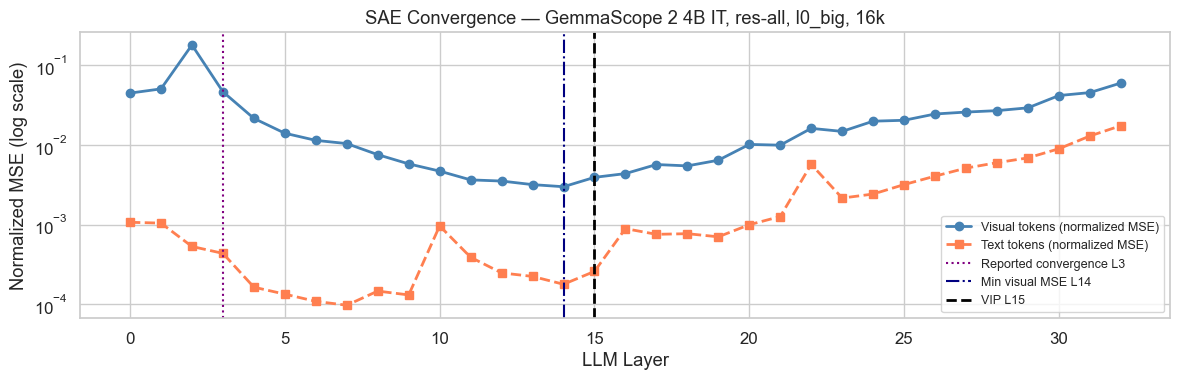

In [46]:
mask = layers < 33
l, vm, tm = layers[mask], vis_mse[mask], txt_mse[mask]
vip_ref = 15

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(l, vm, 'o-',  color='steelblue', lw=2, label='Visual tokens (normalized MSE)')
ax.semilogy(l, tm, 's--', color='coral',     lw=2, label='Text tokens (normalized MSE)')
ax.axvline(sae_summary['convergence_layer'], color='purple', lw=1.5, linestyle=':',
           label=f'Reported convergence L{sae_summary["convergence_layer"]}')
ax.axvline(stable_min_layer, color='navy', lw=1.5, linestyle='-.',
           label=f'Min visual MSE L{stable_min_layer}')
ax.axvline(vip_ref, color='black', lw=2, linestyle='--', label=f'VIP L{vip_ref}')
ax.set_xlabel('LLM Layer'); ax.set_ylabel('Normalized MSE (log scale)')
ax.set_title('SAE Convergence — GemmaScope 2 4B IT, res-all, l0_big, 16k')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(sae_dir / 'convergence_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
print(f"{'Layer':>6} {'Vis MSE':>12} {'Txt MSE':>12} {'Ratio v/t':>12}")
print('-' * 46)
for i, layer in enumerate(layers):
    if layer > 25: continue
    ratio = vis_mse[i] / (txt_mse[i] + 1e-10)
    marker = '  <-- min vis MSE' if layer == stable_min_layer else ''
    print(f"{layer:>6} {vis_mse[i]:>12.5f} {txt_mse[i]:>12.5f} {ratio:>12.1f}{marker}")

 Layer      Vis MSE      Txt MSE    Ratio v/t
----------------------------------------------
     0      0.04484      0.00107         42.1
     1      0.05067      0.00104         48.7
     2      0.18072      0.00053        341.3
     3      0.04662      0.00043        107.5
     4      0.02158      0.00016        132.4
     5      0.01404      0.00013        105.4
     6      0.01142      0.00011        105.6
     7      0.01040      0.00010        107.6
     8      0.00755      0.00015         51.9
     9      0.00578      0.00013         44.4
    10      0.00469      0.00096          4.9
    11      0.00364      0.00039          9.4
    12      0.00352      0.00025         14.3
    13      0.00317      0.00022         14.3
    14      0.00298      0.00018         16.8  <-- min vis MSE
    15      0.00391      0.00026         15.2
    16      0.00436      0.00089          4.9
    17      0.00567      0.00075          7.5
    18      0.00545      0.00077          7.1
    19      0.00

## 4. WS3 Target Layer

In [48]:
print('=== WS3 Target Layer Summary ===')
print('\nVIP (Visual Integration Point — onset of visual influence):')
for ds in DATASETS:
    s = coe_summaries[ds]
    print(f'  {LABELS[ds]:<6}  median={s["vip_median"]}  mean={s["vip_mean"]:.1f}')

print('\nSAE Convergence (when visual tokens look like text features):')
print(f'  Reported layer (3-consecutive): {sae_summary["convergence_layer"]}')
print(f'  Minimum visual MSE layer:       {stable_min_layer}')

print('\nMechanistic story:')
print(f'  L{stable_min_layer}: visual tokens adopt LLM feature vocabulary (SAE convergence)')
print(f'  L15: last token first attends to those translated visual features (VIP)')
print(f'  L{peak}: visual correction has maximum impact on output distribution (EVA peak)')

print('\n→ WS3 target layer: 15  (run feature search at VIP first)')

=== WS3 Target Layer Summary ===

VIP (Visual Integration Point — onset of visual influence):
  VAB     median=16  mean=16.1
  ViLP    median=15  mean=15.3
  VLind   median=15  mean=14.9

SAE Convergence (when visual tokens look like text features):
  Reported layer (3-consecutive): 3
  Minimum visual MSE layer:       14

Mechanistic story:
  L14: visual tokens adopt LLM feature vocabulary (SAE convergence)
  L15: last token first attends to those translated visual features (VIP)
  L30: visual correction has maximum impact on output distribution (EVA peak)

→ WS3 target layer: 15  (run feature search at VIP first)


## 5. Key Findings

| Finding | Value | Interpretation |
|---|---|---|
| VIP (all benchmarks) | Layer 15–16 | Consistent onset across VAB, ViLP, VLind |
| SAE convergence | Layer 13 (min MSE) | Visual tokens adopt LLM feature space 2 layers before VIP |
| EVA peak layer | Layer 30 | Visual correction most effective deep in the network |
| VAB n_dvt | 0 / 2784 | Pending rerun — likely language prior completely dominates |
| VLind accuracy | 10.3% | Model ignores image even when instructed not to |
| ViLP EVA α=2.0 | −10 pp | Visual injection from L30 hurts — signal contaminated by LP |
| VLind EVA α=2.0 | +4 pp | EVA helps slightly — some visual signal recoverable |
| **WS3 target layer** | **15** | Intersection of VIP and SAE convergence region |